# **GEOCLUSTERING**

Objetivo general: obtener agrupamientos geoespaciales compactos, estables y útiles para análisis y modelos posteriores (series de tiempo por zona, perfiles delictivos, asignación rápida de nuevos casos).

Propósito:
    Utilidades geoespaciales y de preparación para el pipeline de clustering.
    Esta versión añade funciones para:
      - Validación de coordenadas y fechas
      - Definición de CRS local y proyección a metros
      - División temporal Holdout
      - Comprobaciones de esquema/columnas

Idea general:
    K-Means requiere métrica euclídea en un espacio en metros.
    Proyectamos lat/lon a un CRS local (ej. Azimuthal Equidistant centrado en la zona de estudio).
    Además, establecemos utilidades para validaciones, consistencia y trazabilidad.

Suposiciones:
    - El DataFrame fuente contiene columnas de latitud/longitud.
    - El proyecto trabaja típicamente en una sola ciudad/región (ej. CDMX).
    - No hay PII expuesta; si hay, se debe anonimizar/filtrar antes.

In [1]:
#!{sys.executable} pip install pyproj

# **1. Librerias**

In [2]:
import os, sys
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")


# **2. CONFIGURACIÓN DEL AMBIENTE**


## 2.1 VARIABLES GLOBALES

In [3]:
# Semilla global para reproducibilidad
SEED = 42

# Mostrar más columnas/filas al explorar
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

In [4]:
# Parámetros globales para clustering
LAT_COL = "latitud"
LON_COL = "longitud"
DATE_COL = "fecha_hecho"       
CATEGORY_COL = "categoria_delito" 

# Centro aproximado (CDMX por defecto)
CENTER_LAT = 19.4326
CENTER_LON = -99.1332
CRS_METHOD = "aeqd"  # 'aeqd' | 'laea' | 'lcc'

# Corte temporal (para holdout en fases posteriores)
# Ejemplo: a partir de 2023-01-01 es test
CUTOFF_DATE = pd.Timestamp("2023-01-01")


In [5]:
# Parámetros de búsqueda de K (para K-means)
K_LIST = [8, 12, 16, 20, 24, 28, 32]
USE_MINIBATCH = True          # True recomendado para datasets grandes
N_INIT = "auto"
MAX_ITER = 300
BATCH_SIZE = 2048

SIL_SAMPLE_SIZE = 10000       # Limita costo de Silhouette; ajusta si tu dataset es pequeño
N_BOOT = 10                   # Número de bootstraps para estabilidad
SAMPLE_FRAC = 0.8             # Fracción por bootstrap

# Pesos del criterio compuesto (puedes ajustar)
WEIGHTS = {
    "silhouette": 0.40,
    "mean_ari":   0.40,
    "chi":        0.15,
    "dbi":        0.05
}


In [6]:
# Inline y DPI más nítido
%matplotlib inline
import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 140

from IPython.display import Image, display, IFrame, HTML

## 2.2 ACCESO A DATOS

In [7]:
# ---- Switch de entorno: "colab" o "local"
RUN_ENV = "local"   # <-- cambia a "local" si no usas Google Colab

# ---- Rutas base
if RUN_ENV.lower() == "colab":
    try:
        from google.colab import drive
        drive.mount("/drive")
    except Exception as e:
        print("Aviso: no se pudo montar Drive automáticamente:", e)
    # Ajusta esta ruta a tu carpeta del proyecto en Drive
    BASE_DIR = "/drive/My Drive/Colab Notebooks/reto-Thales/"
else:
    # Ajusta a tu ruta local del proyecto
    BASE_DIR = "/Users/jorgevalverde/Documents/myEnv/crimen-cdmx/"

os.makedirs(BASE_DIR, exist_ok=True)

# Ruta de los CSVs
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results", "geo_clustering")
os.makedirs(RESULTS_DIR, exist_ok=True)

# Asegurar import de utilidades del proyecto
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

# Guardar artefactos para inferencia ===
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Rutas:")
print(f"Entorno: {RUN_ENV} | BASE_DIR: {BASE_DIR}")
print(" DATA_DIR:", DATA_DIR)
print(" RESULTS_DIR:", RESULTS_DIR)

Rutas:
Entorno: local | BASE_DIR: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/
 DATA_DIR: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/data
 RESULTS_DIR: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results


In [8]:
# Vamos utilizar un archivo de funciones propio
#sys.path.insert(0, BASE_DIR) #para acceder desde Colab-Drive
import myUtils as myUtils

Importing plotly failed. Interactive plots will not work.


# **3. LECTURA DE DATOS**

In [9]:
DATA_PATH = os.path.join(DATA_DIR, "delitos_cdmx_sample_final_5percent.csv")

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Tamanio del dataset: {df.shape}')

Tamanio del dataset: (209873, 21)


In [10]:
# Chequeos de columnas requeridas ---
required_cols = [LAT_COL, LON_COL, DATE_COL]
#myUtils.assert_required_columns(df, required_cols, context="7_GeoClustering - carga inicial")

# Tipos y parsing de fecha (si procede)
if not np.issubdtype(df[DATE_COL].dtype, np.datetime64):
    # Intento de parseo robusto
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce", utc=False)

# Validación de coordenadas
coord_report = myUtils.validate_coordinates(df, lat_col=LAT_COL, lon_col=LON_COL, allow_nulls=False)
print("Reporte coordenadas:", coord_report)

# Drop filas con fecha nula o coordenadas nulas (decisión conservadora; puedes adaptar)
before = len(df)
df = df.dropna(subset=[LAT_COL, LON_COL, DATE_COL]).copy()
after = len(df)
if after < before:
    print(f"Filas eliminadas por nulos en ({LAT_COL}, {LON_COL}, {DATE_COL}): {before - after}")

Reporte coordenadas: {'null_lat': 10159, 'null_lon': 10159, 'out_of_range': 0}
Filas eliminadas por nulos en (latitud, longitud, fecha_hecho): 15222


In [11]:
df

,anio_inicio,mes_inicio,fecha_inicio,hora_inicio,anio_hecho,mes_hecho,fecha_hecho,hora_hecho,delito,competencia,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho,latitud,longitud,categoria_delito
0,2016,Mayo,2016-05-10,00:00:00,2016.0,Abril,2016-04-03,12:28:00,AMENAZAS,NaN,INVESTIGACIÓN EN COYOACÁN,COY-1,UI-1CD,CULHUACÁN CTM SECCIÓN V,Culhuacan Ctm Seccion I,COYOACAN,NaN,CDMX,19.331820,-99.118620,delito de bajo impacto
1,2016,Mayo,2016-05-18,00:00:00,2016.0,Mayo,2016-05-18,15:10:00,LESIONES CULPOSAS POR TRANSITO VEHICULAR EN COLISION,NaN,INVESTIGACIÓN EN CUAUHTEMOC,CUH-2,UI-3CD,DOCTORES,Doctores,CUAUHTEMOC,NaN,CDMX,19.424800,-99.142540,delito de bajo impacto
2,2016,Julio,2016-07-07,00:00:00,2016.0,Mayo,2016-05-16,02:00:00,ROBO DE OBJETOS,NaN,INVESTIGACIÓN EN CUAUHTEMOC,CUH-2,UI-2SD,SANTA MARIA LA RIBERA,Santa Maria La Ribera,CUAUHTEMOC,NaN,CDMX,19.443370,-99.158010,delito de bajo impacto
3,2016,Enero,2016-01-04,00:00:00,2016.0,Enero,2016-01-04,15:30:00,PERDIDA DE LA VIDA POR OTRAS CAUSAS,NaN,INVESTIGACIÓN EN CUAUHTEMOC,CUH-8,UI-3CD,ESPERANZA,Esperanza,CUAUHTEMOC,NaN,CDMX,19.421770,-99.126740,hecho no delictivo
4,2016,Febrero,2016-02-08,00:00:00,2016.0,Febrero,2016-02-01,14:00:00,VIOLENCIA FAMILIAR,NaN,INVESTIGACIÓN EN XOCHIMILCO,XO-2,UI-2SD,LA JOYA,NaN,XOCHIMILCO,NaN,CDMX,19.231226,-99.095951,delito de bajo impacto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208108,2024,Marzo,2024-03-08,14:06:58,2023.0,Abril,2023-04-26,00:00:00,FRAUDE,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN CUAUHTÉMOC,UAT-CUH-7,UI-1SD,ROMA NORTE,Roma Norte,CUAUHTEMOC,NaN,CDMX,19.417802,-99.162692,delito de bajo impacto
208109,2024,Septiembre,2024-09-17,10:15:00,2023.0,Febrero,2023-02-15,10:00:00,FALSIFICACION O ALTERACION Y USO INDEBIDO DE DOCUMENTOS,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN CUAUHTÉMOC,UAT-CUH-8,UI-1SD,DOCTORES,Doctores,CUAUHTEMOC,NaN,CDMX,19.421345,-99.149977,delito de bajo impacto
208110,2024,Mayo,2024-05-18,22:10:00,2024.0,Febrero,2024-02-29,09:12:00,FRAUDE,FUERO COMUN,AGENCIA DE DENUNCIA DIGITAL,CEN-C,UI-1SD,DEL RECREO,Del Recreo,AZCAPOTZALCO,NaN,CDMX,19.476382,-99.184609,delito de bajo impacto
208111,2024,Febrero,2024-02-29,11:33:43,2024.0,Febrero,2024-02-26,08:45:00,ROBO A NEGOCIO SIN VIOLENCIA,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN COYOACÁN,UAT-COY-5,UI-1SD,PUEBLO DE SANTA URSULA COAPA,Pueblo De Santa Ursula Coapa,COYOACAN,NaN,CDMX,19.312313,-99.140882,delito de bajo impacto


In [12]:
# Proyección local en metros 
df_proj = myUtils.project_to_local_meters(
        df,
        lat_col=LAT_COL,
        lon_col=LON_COL,
        center_lat=CENTER_LAT,
        center_lon=CENTER_LON,
        method=CRS_METHOD,
        x_name="x_m",
        y_name="y_m",
        inplace=False,
    )

df_proj[[LAT_COL, LON_COL, "x_m", "y_m"]]

,latitud,longitud,x_m,y_m
0,19.331820,-99.118620,1532.089688,-11155.946440
1,19.424800,-99.142540,-980.904908,-863.411901
2,19.443370,-99.158010,-2605.298134,1192.398226
3,19.421770,-99.126740,678.454302,-1198.838222
4,19.231226,-99.095951,3916.530659,-22290.934311
...,...,...,...,...
208108,19.417802,-99.162692,-3097.408112,-1637.860826
208109,19.421345,-99.149977,-1761.939895,-1245.759422
208110,19.476382,-99.184609,-5397.346226,4847.415330
208111,19.312313,-99.140882,-807.384298,-13315.360110


Se realizan una proyección cartográfica: se transforman las coordenadas geográficas (latitud, longitud), medidas en grados sobre la superficie terrestre, en coordenadas planas expresadas en metros, adecuadas para cálculos euclídeos como los que usa el algoritmo K-Means.

Más concretamente:

- Definen un **sistema de referencia local (CRS)** centrado en un punto de referencia (CENTER_LAT, CENTER_LON, por ejemplo el centro de la CDMX).
- Ese CRS local se construye con una proyección Azimutal Equidistante (AEQD) u otra equivalente, que mantiene las distancias verdaderas desde el centro en metros.

- Transforman cada par (longitud, latitud) del DataFrame df desde el sistema global WGS84 (EPSG:4326) al CRS local. Para ello se utiliza la librería pyproj, que aplica la fórmula matemática de la proyección elegida y devuelve las nuevas coordenadas planas (x_m, y_m).

- Se añaden esas coordenadas proyectadas al nuevo DataFrame df_proj.
Cada punto geográfico pasa a representarse por sus coordenadas en metros respecto al centro definido:

  - x_m: desplazamiento este-oeste en metros

  - y_m: desplazamiento norte-sur en metros

- Con estas nuevas variables (x_m, y_m), pueden aplicar K-Means o cualquier otro algoritmo basado en distancias sin distorsiones por la curvatura terrestre, porque ahora se trabajará en un plano métrico coherente.

De esa manera, con esta proyección se convierte el mapa curvo de la Tierra en un plano local medido en metros, de modo que las distancias entre puntos sean numéricamente consistentes y comparables dentro del área de estudio.

In [13]:
# Sanity check: varianzas/orden de magnitud
print("Rango x_m:", float(df_proj["x_m"].min()), "->", float(df_proj["x_m"].max()))
print("Rango y_m:", float(df_proj["y_m"].min()), "->", float(df_proj["y_m"].max()))

Rango x_m: -21831.548542554956 -> 19579.94177749381
Rango y_m: -33894.07025201345 -> 16645.7111918312


# **4. SELECCIÓN DEL MEJOR K**

In [14]:
df_metrics, BEST_K = myUtils.search_kmeans_k(
    df_proj,
    x_col="x_m",
    y_col="y_m",
    k_list=K_LIST,
    use_minibatch=USE_MINIBATCH,
    random_state=SEED,
    n_init=N_INIT,
    max_iter=MAX_ITER,
    batch_size=BATCH_SIZE,
    silhouette_sample_size=SIL_SAMPLE_SIZE,
    n_boot=N_BOOT,
    sample_frac=SAMPLE_FRAC,
    weights=WEIGHTS,
)

print("K recomendado (criterio compuesto):", BEST_K)

K recomendado (criterio compuesto): 20


In [15]:
df_metrics

,k,silhouette,dbi,chi,mean_ari,std_ari
0,8,0.334360,0.871560,144767.226864,0.504527,0.074799
1,12,0.348363,0.840487,150886.986658,0.632376,0.078279
2,16,0.343533,0.849152,154904.251048,0.571370,0.057172
3,20,0.361932,0.794405,160102.253782,0.541982,0.057111
4,24,0.355565,0.825577,161921.466144,0.549963,0.043073
5,28,0.350068,0.804917,160064.115996,0.554940,0.032749
6,32,0.340484,0.819575,157552.707159,0.532241,0.029281


Las métricas permiten evaluar cuán bien se estructuran y se mantienen los clusters al variar el número de grupos (K):

- **Silhouette (↑ mejor):** mide la separación y compacidad de los clusters. Los valores más altos indican fronteras bien definidas.  
- **Davies–Bouldin (↓ mejor):** evalúa la relación entre dispersión interna y separación entre clusters. Valores bajos reflejan grupos más diferenciados.
  
- **Calinski–Harabasz (↑ mejor):** compara la varianza entre clusters con la varianza interna; mayores valores sugieren estructura espacial más marcada.
  
- **mean_ARI (↑ mejor):** estima la **estabilidad** del modelo ante submuestras (robustez del agrupamiento).  
- **std_ARI (↓ mejor):** mide la variabilidad de esa estabilidad; valores bajos implican consistencia entre corridas.

En nuestro caso:
- **K = 12** muestra la **mayor estabilidad (ARI)**, con regiones amplias y reproducibles.  
- **K = 20** ofrece la **mejor separación espacial (Silhouette y DBI)**, con clusters más definidos.  
- A partir de K > 24 no se observan mejoras relevantes.  

En síntesis, **K = 12** es más estable, mientras que **K = 20** logra mejor resolución geográfica.


In [16]:
# Guardar métricas para auditoría / comparación
metrics_path = os.path.join(RESULTS_DIR, "k_search_metrics.csv")
df_metrics.to_csv(metrics_path, index=False, encoding="utf-8")
print("Métricas de búsqueda de K guardadas en:", metrics_path)

Métricas de búsqueda de K guardadas en: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/k_search_metrics.csv


# **5. DIVISIÓN TEMPORAL DE ENTRENAMIENTO Y PRUEBA**

In [17]:
df_train, df_test = myUtils.temporal_holdout_split(
    df_proj,
    date_col=DATE_COL,
    cutoff=CUTOFF_DATE,
    include_cutoff_in="test"
)

print(f"Tamaño TRAIN: {len(df_train):,} | TEST: {len(df_test):,}")

Tamaño TRAIN: 155,530 | TEST: 39,121


# **6. ENTRENAR MODELO DE CLUSTERING**

In [18]:
# Entrenar modelo final con el mejor K
final_model, centroids = myUtils.train_final_kmeans(
    df_train,
    k=BEST_K,
    x_col="x_m",
    y_col="y_m",
    use_minibatch=True,
    random_state=SEED,
)

final_model

MiniBatchKMeans(batch_size=2048, max_iter=300, n_clusters=20, random_state=42)

In [19]:
centroids

array([[   639.36303732,  -9225.76743415],
       [ -1725.97465377,   3929.33733742],
       [ -3879.90483784,  -7465.81674523],
       [  7516.21765909, -12858.55223199],
       [  5645.91735356,  -2026.112515  ],
       [  -498.71801176,   -991.07721566],
       [-14581.95632419,  -8449.75916163],
       [ 11467.86566605,  -8261.38155237],
       [ -4710.71991637, -17329.37265319],
       [-10217.14057611, -13876.5289623 ],
       [ 12790.83820712, -20826.29931822],
       [  1786.77009367,   5827.84792316],
       [ -6591.76525595,   5664.0473078 ],
       [ -6783.41961672,  -4625.34376033],
       [  -268.69001208, -14102.80393272],
       [ -1095.2609773 ,  11509.70923703],
       [ -4787.59374061,    313.71912206],
       [  2332.71848894, -21191.67905882],
       [  4921.9638764 ,   3591.82745387],
       [  4185.77024717,  -6025.63140995]])

# **7. TEST DEL MODELO DE CLUSTERING**

In [20]:
# Asignar clusters a los datos de prueba
df_test_pred = myUtils.assign_clusters_to_new_points(final_model, df_test)
df_test_pred

,anio_inicio,mes_inicio,fecha_inicio,hora_inicio,anio_hecho,mes_hecho,fecha_hecho,hora_hecho,delito,competencia,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho,latitud,longitud,categoria_delito,x_m,y_m,cluster_id
160643,2023,Julio,2023-07-23,21:45:31,2023.0,Mayo,2023-05-18,12:00:00,COBRANZA ILEGITIMA,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLÁHUAC,UAT-TLH-1,3 SIN DETENIDO,DEL MAR,Del Mar,TLAHUAC,NaN,CDMX,19.290177,-99.063825,delito de bajo impacto,7291.875688,-15764.295303,3
160644,2023,Marzo,2023-03-21,19:17:51,2023.0,Marzo,2023-03-21,16:00:00,VIOLENCIA FAMILIAR,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN IZTAPALAPA,IZP-6,UI-2SD,CENTRAL DE ABASTO,Central De Abasto,IZTAPALAPA,NaN,CDMX,19.372224,-99.098980,delito de bajo impacto,3595.017451,-6683.046264,19
160645,2023,Agosto,2023-08-31,23:55:07,2023.0,Agosto,2023-08-31,21:30:00,LESIONES INTENCIONALES POR GOLPES,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN CUAUHTÉMOC,STCMZV,UI-3CD,SANTA CRUZ ATOYAC,Santa Cruz Atoyac,BENITO JUAREZ,NaN,CDMX,19.370765,-99.164762,delito de bajo impacto,-3315.844685,-6844.694370,2
160646,2023,Mayo,2023-05-14,00:02:27,2023.0,Mayo,2023-05-13,21:00:00,VIOLENCIA FAMILIAR,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN XOCHIMILCO,UAT-XO-2,UI-1SD,SANTA CRUZ ACALPIXCA - PUEBLO,Pueblo Santa Cruz Acalpixca,XOCHIMILCO,NaN,CDMX,19.246086,-99.076164,delito de bajo impacto,5996.536108,-20645.361355,17
160647,2023,Diciembre,2023-12-27,20:36:13,2023.0,Diciembre,2023-12-23,10:30:00,LESIONES INTENCIONALES,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN DE DELITOS COMETIDOS EN AGRAVIO DE GRUPOS DE ATENCIÓN PRIORITARIA,GAP,Unidad de investigación AM-1 C/D,SANTA MARÍA NONOALCO,Barrio Santa Maria Nonoalco,ALVARO OBREGON,NaN,CDMX,19.381214,-99.192827,delito de bajo impacto,-6263.863373,-5687.229401,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208107,2024,Marzo,2024-03-11,01:12:08,2024.0,Marzo,2024-03-10,23:05:00,DAÑO EN PROPIEDAD AJENA CULPOSA POR TRÁNSITO VEHICULAR A AUTOMOVIL,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN COYOACÁN,COY-2,UI-3CD,AMPLIACION SAN FRANCISCO CULHUACAN,Ex-Ejido De San Francisco Culhuacan,COYOACAN,NaN,CDMX,19.337603,-99.122853,delito de bajo impacto,1087.274572,-10515.777656,0
208108,2024,Marzo,2024-03-08,14:06:58,2023.0,Abril,2023-04-26,00:00:00,FRAUDE,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN CUAUHTÉMOC,UAT-CUH-7,UI-1SD,ROMA NORTE,Roma Norte,CUAUHTEMOC,NaN,CDMX,19.417802,-99.162692,delito de bajo impacto,-3097.408112,-1637.860826,16
208109,2024,Septiembre,2024-09-17,10:15:00,2023.0,Febrero,2023-02-15,10:00:00,FALSIFICACION O ALTERACION Y USO INDEBIDO DE DOCUMENTOS,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN CUAUHTÉMOC,UAT-CUH-8,UI-1SD,DOCTORES,Doctores,CUAUHTEMOC,NaN,CDMX,19.421345,-99.149977,delito de bajo impacto,-1761.939895,-1245.759422,5
208110,2024,Mayo,2024-05-18,22:10:00,2024.0,Febrero,2024-02-29,09:12:00,FRAUDE,FUERO COMUN,AGENCIA DE DENUNCIA DIGITAL,CEN-C,UI-1SD,DEL RECREO,Del Recreo,AZCAPOTZALCO,NaN,CDMX,19.476382,-99.184609,delito de bajo impacto,-5397.346226,4847.415330,12


In [21]:
df_test_pred[[DATE_COL, "x_m", "y_m", "cluster_id"]]

,fecha_hecho,x_m,y_m,cluster_id
160643,2023-05-18,7291.875688,-15764.295303,3
160644,2023-03-21,3595.017451,-6683.046264,19
160645,2023-08-31,-3315.844685,-6844.694370,2
160646,2023-05-13,5996.536108,-20645.361355,17
160647,2023-12-23,-6263.863373,-5687.229401,13
...,...,...,...,...
208107,2024-03-10,1087.274572,-10515.777656,0
208108,2023-04-26,-3097.408112,-1637.860826,16
208109,2023-02-15,-1761.939895,-1245.759422,5
208110,2024-02-29,-5397.346226,4847.415330,12


In [22]:
consistency = myUtils.evaluate_temporal_consistency(
    df_train,
    df_test_pred,
    cluster_col="cluster_id",
    category_col=CATEGORY_COL,
)

print("Evaluación de consistencia temporal:")
for k, v in consistency.items():
    print(f"  {k}: {v:.4f}")

Evaluación de consistencia temporal:
  kl_clusters: 0.0035
  kl_categories_mean: 0.0247
  kl_categories_std: 0.0107


* kl_clusters: mide cuánto cambia la distribución de clusters entre train y test (↓ mejor, ideal < 0.15).

* kl_categories_mean: divergencia media entre distribuciones de categorías por cluster (↓ mejor).

* kl_categories_std: variabilidad entre clusters (baja = comportamiento homogéneo).

In [23]:
artifacts = myUtils.save_geo_kmeans_artifacts(
    final_model,
    centroids,
    results_dir=RESULTS_DIR,
    prefix="geo_kmeans_final",
    center_lat=CENTER_LAT,
    center_lon=CENTER_LON,
    crs_method=CRS_METHOD,
    best_k=BEST_K,
)

print("Artefactos guardados:")
for k, v in artifacts.items():
    print(f" - {k}: {v}")

Artefactos guardados:
 - model: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/geo_kmeans_final_model.joblib
 - centroids: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/geo_kmeans_final_centroids.csv
 - meta: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/geo_kmeans_final_meta.json


# **8. VISUALIZACIÓN**

## 8.1 Análisis de K

Figuras de selección de K:
 - silhouette: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/k_selection_silhouette_vs_k.png
 - dbi: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/k_selection_dbi_vs_k.png
 - chi: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/k_selection_chi_vs_k.png
silhouette: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/k_selection_silhouette_vs_k.png


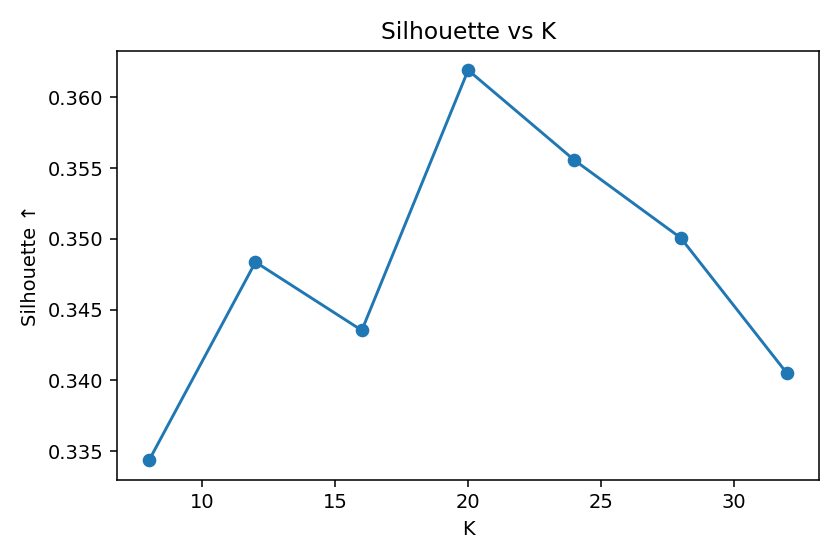

dbi: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/k_selection_dbi_vs_k.png


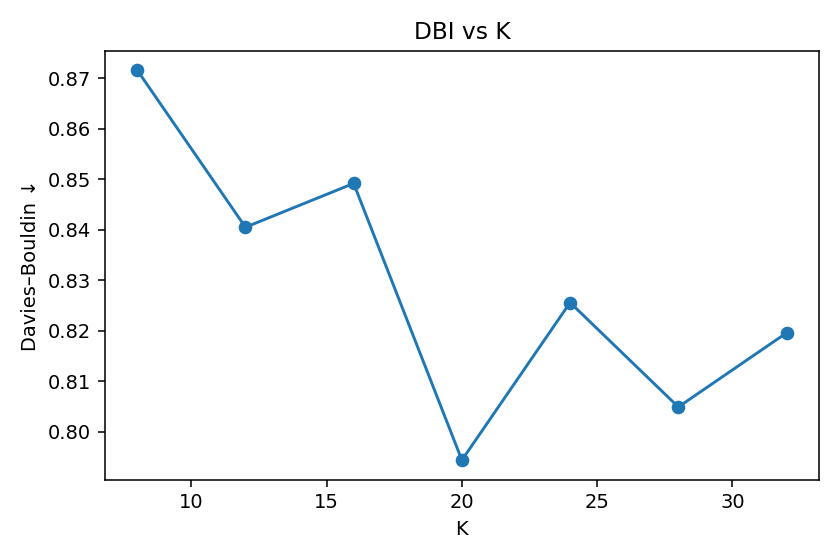

chi: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/k_selection_chi_vs_k.png


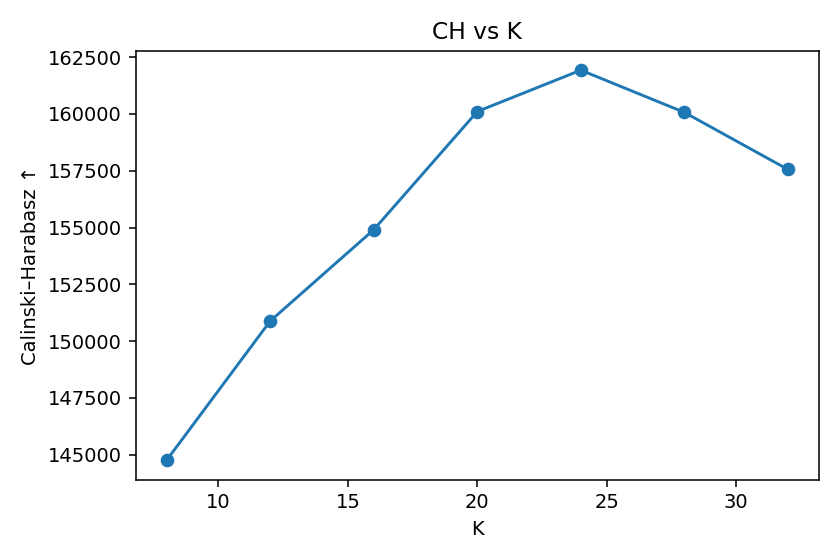

In [24]:

k_figs = myUtils.plot_k_selection(
    df_metrics,
    save_dir=RESULTS_DIR,
    filename_prefix="k_selection"
)
print("Figuras de selección de K:")
for k, p in k_figs.items():
    print(f" - {k}: {p}")

for name, path in k_figs.items():
    print(f"{name}: {path}")
    if os.path.exists(path):
        display(Image(filename=path))
    else:
        print("No se encontró el archivo:", path)

## 8.2 Visualización en mapa

In [25]:
# Usamos TRAIN para el mapa (menos puntos que todo el set); ajusta si prefieres otro subconjunto
myUtils.make_cluster_map_inline(
    df_points=df_train,
    centroids_xy=centroids,
    center_lat=CENTER_LAT,
    center_lon=CENTER_LON,
    crs_method=CRS_METHOD,
    cluster_col="cluster_id",
    max_points=5000
)


## 8.3 Perfil de los clusters

Perfiles guardados:
 - distance_boxplot: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/cluster_profiles_distance_boxplot.png
 - category_composition: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/cluster_profiles_category_composition.png


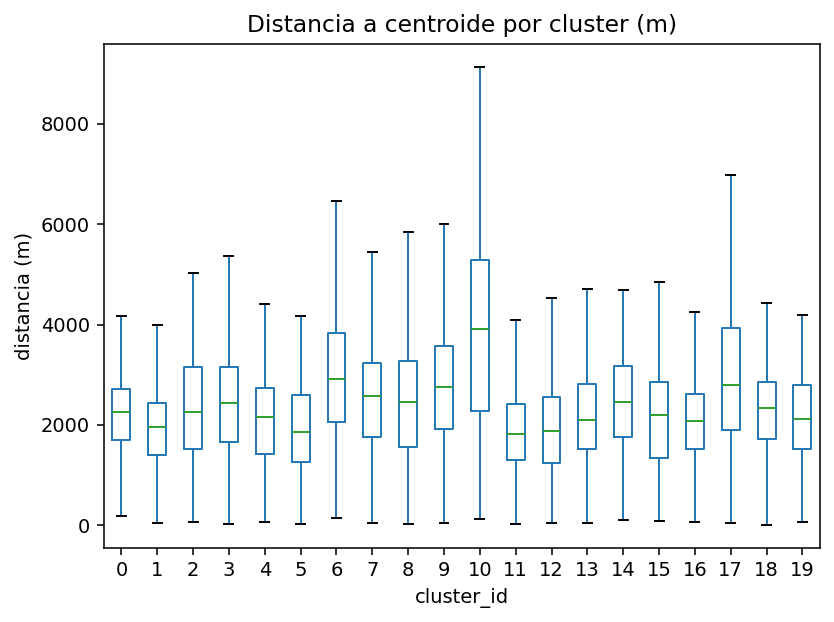

In [26]:
profile_figs = myUtils.plot_cluster_profiles(
    df=df_train,                # perfiles sobre train (más estable)
    centroids_xy=centroids,
    save_dir=RESULTS_DIR,
    cluster_col="cluster_id",
    category_col=CATEGORY_COL,  # si no existe, pasará solo distancia
    filename_prefix="cluster_profiles"
)
print("Perfiles guardados:")
for k, p in profile_figs.items():
    print(f" - {k}: {p}")

## 8.4 Series Temporales de los clusters

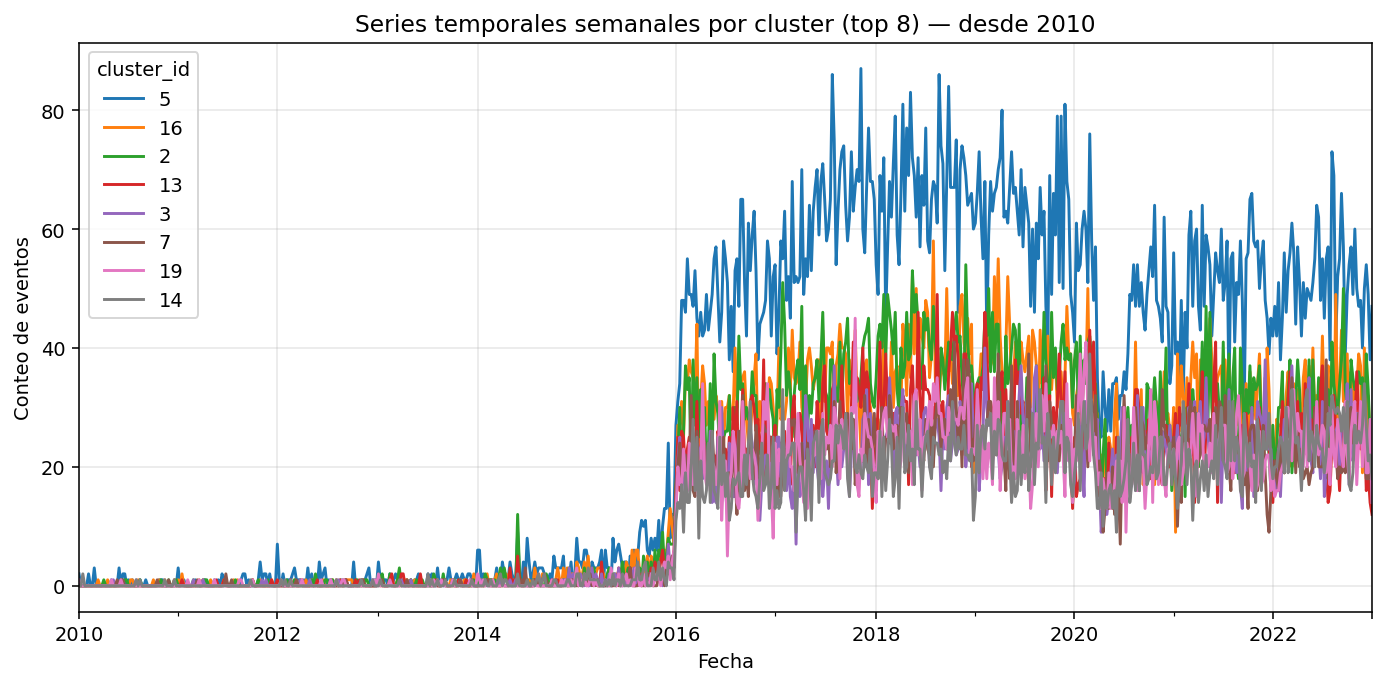

In [28]:
# Mostrar las series temporales desde 2010
ts_w = myUtils.plot_cluster_timeseries_inline(
    df=df_train,
    date_col=DATE_COL,
    cluster_col="cluster_id",
    freq="W",
    start_year=2010,
    top_n=8
)